# Linking phenotypes for drug perturbations in Prophet

Before bringing in single-cell data, we map — **within the Prophet datasets** — which phenotype
readouts are available for each drug perturbation. A given `(cell_line, drug)` pair can carry several
readouts across datasets (viability / IC50, Log2FC, transcriptional RNA, Cell-Painting morphology).
Perturbations with **multiple** phenotypes are the substrate for learning/using a phenotype
representation.

We compute:
1. **Inventory** of the drug-phenotype datasets.
2. **Cell-line and drug overlap** across datasets (UpSet plots).
3. **Phenotype linkage**: how many `(cell_line, drug)` pairs (and drugs) are covered by 1, 2, … readouts,
   the dataset co-occurrence, and the linkage table itself.

Reuses the cached Prophet sets built by `prophet_overlap.py` (`_cache/prophet_sets.pkl`).

In [1]:
import pickle
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

TAB = Path("tables"); TAB.mkdir(exist_ok=True)
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

ps, _ = pickle.load(open("_cache/prophet_sets.pkl", "rb"))
print("cached Prophet datasets:", list(ps))

cached Prophet datasets: ['GDSC', 'GDSC2', 'CTRP', 'PRISM', 'SCORE', 'Horlbeck', 'JUMP', 'JUMPcr', 'JUMPsm', 'LINCS', 'Shifrut', 'PRISM_csv']


## Drug-phenotype datasets

Small-molecule (drug) phenotype datasets only — CRISPR/genetic screens (SCORE, Horlbeck, JUMPcr,
Shifrut) are excluded here. `GDSC2` is drug *combinations* (its pairs live in a different space), so
it's included in the cell-line/drug overlaps but excluded from the singleton pair-linkage.

In [2]:
DRUG = {                       # name -> (readout, is_singleton_pair_space)
    "GDSC":   ("viability ln(IC50)",        True),
    "GDSC2":  ("viability ln(IC50) [combo]", False),
    "CTRP":   ("viability IC50",            True),
    "PRISM":  ("Log2FC / MFI",              True),
    "LINCS":  ("RNA fluorescence (978d)",   True),
    "JUMPsm": ("Cell Painting (200d)",      True),
}
inv = pd.DataFrame([dict(dataset=d, readout=r,
            n_cell_lines=len(ps[d]["cell_lines"]), n_drugs=len(ps[d]["drugs"]),
            n_pairs=len(ps[d]["pairs"]), n_readout_dims=ps[d]["n_readout"])
        for d, (r, _) in DRUG.items()])
inv

,dataset,readout,n_cell_lines,n_drugs,n_pairs,n_readout_dims
0,GDSC,viability ln(IC50),967,298,234757,1
1,GDSC2,viability ln(IC50) [combo],122,65,109712,1
2,CTRP,viability IC50,887,696,1579,1
3,PRISM,Log2FC / MFI,567,4028,2229444,1
4,LINCS,RNA fluorescence (978d),69,6536,62322,978
5,JUMPsm,Cell Painting (200d),2,310,600,200


## Cell-line & drug overlap across datasets (UpSet)

Each bar is an exact intersection — the number of cell lines (or drugs) belonging to *exactly* that
combination of datasets. The dot matrix below the bar marks which datasets are in the combination.

In [3]:
def upset(contents, title, top=25, min_size=1, savepath=None, figsize=(13, 6)):
    """Minimal UpSet plot from {name: set}. Bars = exact-intersection sizes."""
    names = list(contents)
    universe = set().union(*contents.values())
    membership = Counter()
    for e in universe:
        key = tuple(i for i, n in enumerate(names) if e in contents[n])
        if key:
            membership[key] += 1
    combos = [c for c in sorted(membership.items(), key=lambda kv: -kv[1]) if c[1] >= min_size][:top]
    sizes = [c[1] for c in combos]
    nset = len(names)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 6], height_ratios=[3, 1.4], hspace=0.05, wspace=0.05)
    ax_bar = fig.add_subplot(gs[0, 1])
    ax_dot = fig.add_subplot(gs[1, 1], sharex=ax_bar)
    ax_set = fig.add_subplot(gs[1, 0], sharey=ax_dot)

    x = range(len(combos))
    ax_bar.bar(x, sizes, color="#3b6ea5")
    for xi, s in zip(x, sizes):
        ax_bar.text(xi, s, str(s), ha="center", va="bottom", fontsize=6, rotation=0)
    ax_bar.set_ylabel("intersection size"); ax_bar.set_title(title); ax_bar.set_xticks([])
    ax_bar.spines[["top", "right"]].set_visible(False)

    for ci, (key, _) in enumerate(combos):
        members = set(key)
        for si in range(nset):
            ax_dot.scatter(ci, nset - 1 - si, s=55,
                           color="#333" if si in members else "#dddddd", zorder=2)
        ys = [nset - 1 - si for si in members]
        if len(ys) > 1:
            ax_dot.plot([ci, ci], [min(ys), max(ys)], color="#333", lw=1.5, zorder=1)
    ax_dot.set_xticks([]); ax_dot.set_yticks(range(nset))
    ax_dot.set_yticklabels([]); ax_dot.set_xlim(-0.6, len(combos) - 0.4)
    ax_dot.set_ylim(-0.6, nset - 0.4)
    for s in ax_dot.spines.values(): s.set_visible(False)

    set_sizes = [len(contents[n]) for n in names]
    ax_set.barh(range(nset), [set_sizes[nset - 1 - i] for i in range(nset)], color="#888")
    ax_set.set_yticks(range(nset)); ax_set.set_yticklabels(names[::-1], fontsize=8)
    ax_set.invert_xaxis(); ax_set.set_xlabel("set size", fontsize=7)
    ax_set.spines[["top", "left"]].set_visible(False)
    if savepath:
        fig.savefig(savepath, dpi=130, bbox_inches="tight")
    plt.show()

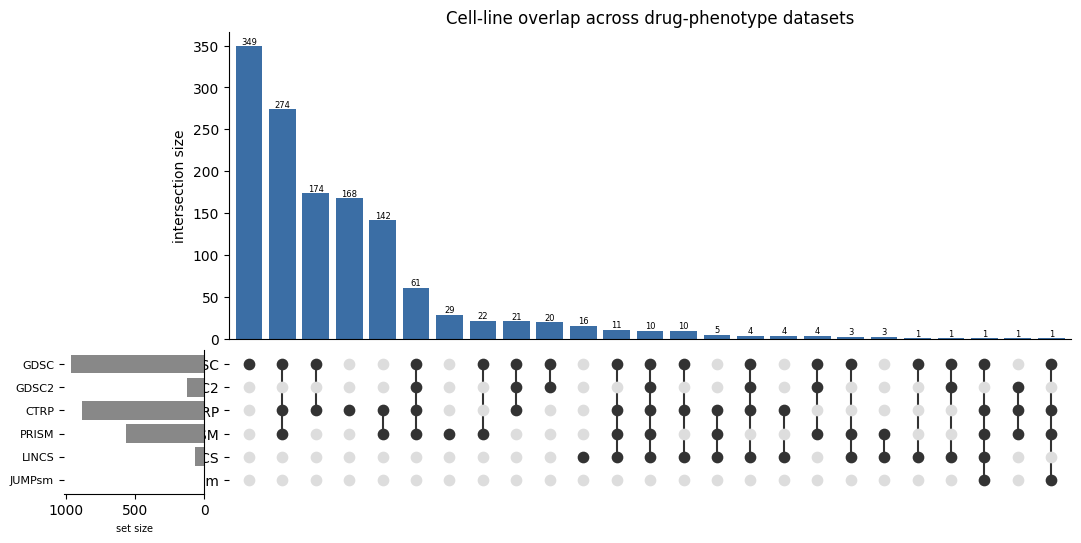

In [4]:
upset({d: ps[d]["cell_lines"] for d in DRUG},
      "Cell-line overlap across drug-phenotype datasets",
      savepath=FIG / "upset_cell_lines.png")

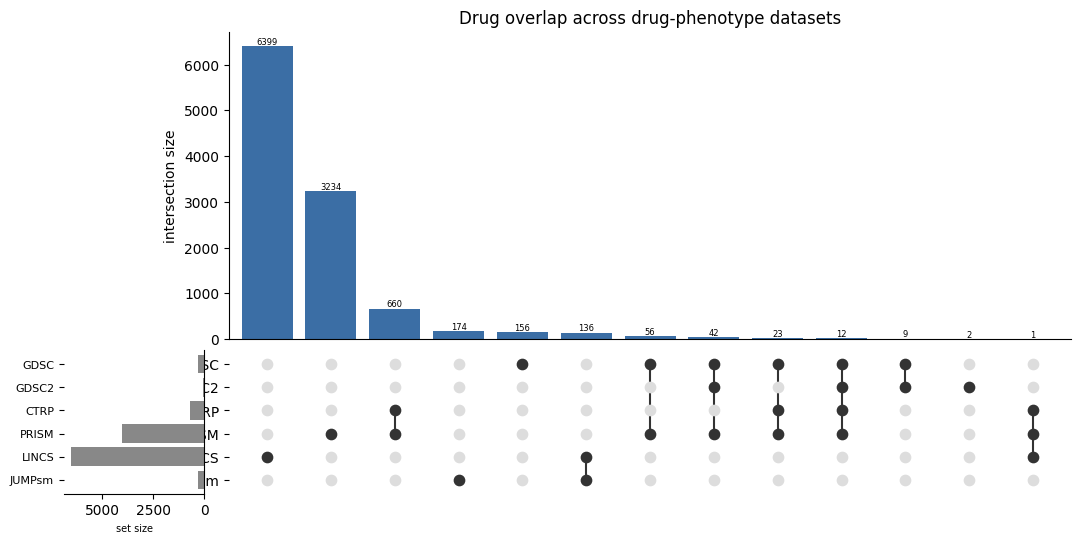

In [5]:
upset({d: ps[d]["drugs"] for d in DRUG},
      "Drug overlap across drug-phenotype datasets",
      savepath=FIG / "upset_drugs.png")

## Phenotype linkage: how many readouts per perturbation

For the singleton datasets, count how many phenotype readouts each `(cell_line, drug)` pair (and each
drug) is measured by. Pairs/drugs with ≥2 readouts are the multi-modal candidates.

distinct (cell_line, drug) pairs: 2,481,823
distinct drugs:                   10,902


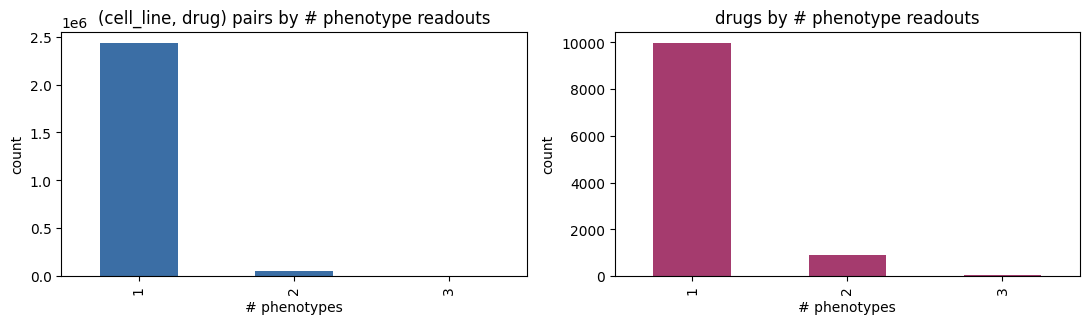

,# pairs,# drugs
# phenotypes,,
1,2434971,9972
2,46825,894
3,27,36


In [6]:
singleton = [d for d, (_, s) in DRUG.items() if s]

pair_count = Counter()
for d in singleton:
    for p in ps[d]["pairs"]:
        pair_count[p] += 1
pair_hist = pd.Series(Counter(pair_count.values())).sort_index()
pair_hist.index.name = "# phenotypes"; pair_hist.name = "# pairs"

drug_count = Counter()
for d in singleton:
    for g in ps[d]["drugs"]:
        drug_count[g] += 1
drug_hist = pd.Series(Counter(drug_count.values())).sort_index()
drug_hist.index.name = "# phenotypes"; drug_hist.name = "# drugs"

print(f"distinct (cell_line, drug) pairs: {len(pair_count):,}")
print(f"distinct drugs:                   {len(drug_count):,}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
pair_hist.plot.bar(ax=ax[0], color="#3b6ea5"); ax[0].set_title("(cell_line, drug) pairs by # phenotype readouts")
drug_hist.plot.bar(ax=ax[1], color="#a53b6e"); ax[1].set_title("drugs by # phenotype readouts")
for a in ax: a.set_ylabel("count")
fig.tight_layout(); fig.savefig(FIG / "phenotypes_per_perturbation.png", dpi=130); plt.show()
pd.concat([pair_hist, drug_hist], axis=1)

### Dataset co-occurrence — shared `(cell_line, drug)` pairs

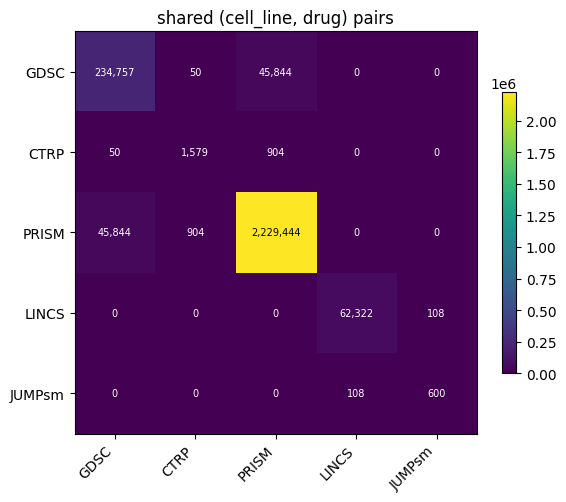

,GDSC,CTRP,PRISM,LINCS,JUMPsm
GDSC,234757,50,45844,0,0
CTRP,50,1579,904,0,0
PRISM,45844,904,2229444,0,0
LINCS,0,0,0,62322,108
JUMPsm,0,0,0,108,600


In [7]:
M = pd.DataFrame(
    [[len(ps[a]["pairs"] & ps[b]["pairs"]) for b in singleton] for a in singleton],
    index=singleton, columns=singleton)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M.values, cmap="viridis")
ax.set_xticks(range(len(singleton))); ax.set_xticklabels(singleton, rotation=45, ha="right")
ax.set_yticks(range(len(singleton))); ax.set_yticklabels(singleton)
for i in range(len(singleton)):
    for j in range(len(singleton)):
        ax.text(j, i, f"{M.values[i,j]:,}", ha="center", va="center", fontsize=7,
                color="white" if im.norm(M.values[i,j]) < 0.6 else "black")
ax.set_title("shared (cell_line, drug) pairs"); fig.colorbar(im, shrink=0.7)
fig.tight_layout(); fig.savefig(FIG / "pair_cooccurrence.png", dpi=130); plt.show()
M

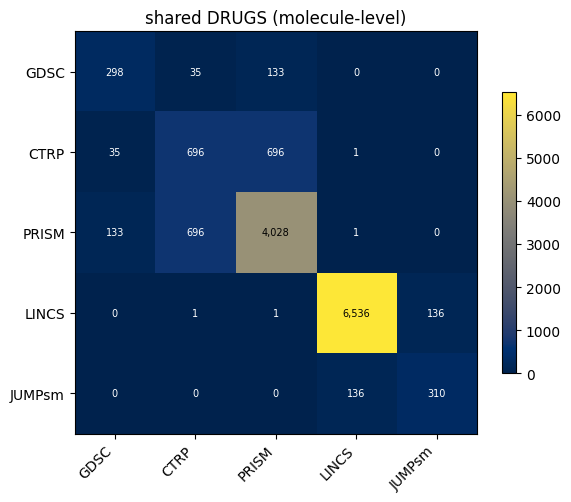

,GDSC,CTRP,PRISM,LINCS,JUMPsm
GDSC,298,35,133,0,0
CTRP,35,696,696,1,0
PRISM,133,696,4028,1,0
LINCS,0,1,1,6536,136
JUMPsm,0,0,0,136,310


In [8]:
# drug-level (molecule) co-occurrence: can phenotypes be linked by DRUG even when not by pair?
Md = pd.DataFrame(
    [[len(ps[a]["drugs"] & ps[b]["drugs"]) for b in singleton] for a in singleton],
    index=singleton, columns=singleton)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Md.values, cmap="cividis")
ax.set_xticks(range(len(singleton))); ax.set_xticklabels(singleton, rotation=45, ha="right")
ax.set_yticks(range(len(singleton))); ax.set_yticklabels(singleton)
for i in range(len(singleton)):
    for j in range(len(singleton)):
        ax.text(j, i, f"{Md.values[i,j]:,}", ha="center", va="center", fontsize=7,
                color="white" if im.norm(Md.values[i, j]) < 0.6 else "black")
ax.set_title("shared DRUGS (molecule-level)"); fig.colorbar(im, shrink=0.7)
fig.tight_layout(); fig.savefig(FIG / "drug_cooccurrence.png", dpi=130); plt.show()
Md

### The linkage table & richest multi-phenotype perturbations

In [9]:
rows = []
for p, c in pair_count.items():
    present = [d for d in singleton if p in ps[d]["pairs"]]
    rows.append(dict(cell_line=p[0], drug=p[1], n_phenotypes=c, datasets=";".join(present)))
link = pd.DataFrame(rows).sort_values(["n_phenotypes"], ascending=False).reset_index(drop=True)
link.to_csv(TAB / "drug_phenotype_linkage.csv", index=False)
print(f"linkage table: {link.shape[0]:,} pairs  →  tables/drug_phenotype_linkage.csv")
print("pairs with >=2 phenotypes:", int((link.n_phenotypes >= 2).sum()))
print("pairs with >=3 phenotypes:", int((link.n_phenotypes >= 3).sum()))
link.head(20)

linkage table: 2,481,823 pairs  →  tables/drug_phenotype_linkage.csv
pairs with >=2 phenotypes: 46852
pairs with >=3 phenotypes: 27


,cell_line,drug,n_phenotypes,datasets
0,HT115,bi2536,3,GDSC;CTRP;PRISM
1,COLO680N,a366,3,GDSC;CTRP;PRISM
2,OBSOLETET47D,ly2109761,3,GDSC;CTRP;PRISM
3,HGC27,azd4547,3,GDSC;CTRP;PRISM
4,HT1080,bi2536,3,GDSC;CTRP;PRISM
5,IGROV1,bms345541,3,GDSC;CTRP;PRISM
6,NCIH2087,epz004777,3,GDSC;CTRP;PRISM
7,JHH1,bms754807,3,GDSC;CTRP;PRISM
8,GB1,amg319,3,GDSC;CTRP;PRISM
9,NCIH2087,epz5676,3,GDSC;CTRP;PRISM


## Findings

**The drug-phenotype datasets form two near-disjoint "islands."**

- **Viability / drug-response** — GDSC, CTRP, PRISM (scalar IC50 / Log2FC). They overlap heavily: all
  696 CTRP drugs are in PRISM, GDSC shares 133 drugs with PRISM, and **GDSC ∩ PRISM = 45,844 shared
  `(cell_line, drug)` pairs**.
- **Molecular phenotype** — LINCS (978-d RNA), JUMPsm (200-d Cell Painting). They share 136 drugs /
  108 pairs with *each other* but **≈0 with the viability cluster**.

**Multi-modal linkage at the pair level is essentially absent.** Of **2,481,823** distinct
`(cell_line, drug)` pairs, **98.1% carry a single readout**; 46,825 have 2 and only **27 have 3** — and
every multi-readout pair sits *inside* the viability cluster (the 3-readout pairs are GDSC+CTRP+PRISM,
i.e. three viability assays measuring the same thing). **No pair carries viability + transcriptomics +
morphology together.**

**At the molecule level it's the same picture — but partly a harmonization artifact.** LINCS shares
only **1** drug with PRISM and **0** with GDSC by name-matching. LINCS (Connectivity Map) and PRISM
(both Broad) certainly share far more chemistry than that, so the LINCS/JUMP ↔ viability gap is
**dominated by drug-identifier mismatch** (different naming conventions), not true biological
disjointness. The viability cluster overlaps well only because GDSC/CTRP/PRISM share a compound-name
convention. **We cannot measure the true cross-modal overlap until drug ids are harmonized to a
canonical structure (InChIKey / SMILES).**

### Implications

1. **Readily usable today:** the **scalar drug-response** phenotype (PRISM Log2FC / GDSC IC50) —
   millions of `(cell_line, drug)` pairs, ~47k with ≥2 independent viability assays. Low-dimensional
   but abundant and self-consistent → the natural first phenotype to condition on.
2. **Rich molecular phenotypes** (LINCS RNA, JUMP morphology) live on their own cell-line/chemistry
   panels; fusing them with viability — or each other — at the perturbation level is blocked by
   (a) disjoint cell-line panels and (b) unresolved drug-id mapping.
3. **Next step before any phenotype fusion:** harmonize drug identifiers (name → InChIKey/SMILES via a
   structure resolver) and re-run this linkage. That determines whether multi-modal phenotype
   conditioning is feasible at all, or whether we are limited to scalar drug-response.

_Outputs: `tables/drug_phenotype_linkage.csv`; figures `upset_cell_lines.png`, `upset_drugs.png`,
`phenotypes_per_perturbation.png`, `pair_cooccurrence.png`, `drug_cooccurrence.png`._